In [7]:
import os
import numpy as np
import pandas as pd

RESULT_ROOT = "result_instance_5algo_with_stop_time_56"

ALGOS_ALL = [
    "NSGA_II",
    "MOEA_D",
    "PFG_MOEA",
    "PFG_MOEA_D",
    "PFG_MOEA_D_VER2"
]

BASE = "PFG_MOEA_D"

BASE_ALGOS = [
    "NSGA_II",
    "MOEA_D",
    "PFG_MOEA",
    "PFG_MOEA_D"
]


# LOAD PF 
def load_pf(path):
    df = pd.read_csv(path)
    return df[["makespan", "carbon"]].values


# NORMALIZE 
def normalize_pf_dict(pf_dict):

    all_points = np.vstack(list(pf_dict.values()))

    min_vals = all_points.min(axis=0)
    max_vals = all_points.max(axis=0)

    norm_pf = {}

    for k, v in pf_dict.items():
        norm_pf[k] = (v - min_vals) / (max_vals - min_vals + 1e-9)

    return norm_pf


# NON-DOMINATED 
def get_non_dominated(points):

    points = np.unique(points, axis=0)
    n = len(points)

    is_dominated = np.zeros(n, dtype=bool)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            # j dominates i
            if np.all(points[j] <= points[i]) and np.any(points[j] < points[i]):
                is_dominated[i] = True
                break

    return points[~is_dominated]

# BUILD REFERENCE PF 
def build_reference_pf(pf_norm):

    union_pf = np.vstack([pf_norm[a] for a in BASE_ALGOS])
    
    return get_non_dominated(union_pf)


# HV 
def hypervolume(F, ref):

    F = F[F[:, 0].argsort()]

    hv = 0.0
    prev_x = ref[0]

    for x, y in F[::-1]:
        hv += (prev_x - x) * (ref[1] - y)
        prev_x = x

    return hv


# IGD (FIX CHUẨN)
def igd(F, ref_pf):

    distances = np.linalg.norm(ref_pf[:, None, :] - F[None, :, :], axis=2)

    return np.mean(np.min(distances, axis=1))


# C-METRIC
def dominates(a, b):
    return np.all(a <= b) and np.any(a < b)


def c_metric(A, B):

    count = 0

    for b in B:
        if np.any(np.all(A <= b, axis=1) & np.any(A < b, axis=1)):
            count += 1

    return count / len(B)


# MAIN
excel_hv = []
excel_igd = []
excel_c = []
excel_makespan = []
excel_co2 = []

folders = sorted([
    f for f in os.listdir(RESULT_ROOT)
    if f.startswith("result_")
])

print("Total folders:", len(folders))


for folder in folders:

    path = os.path.join(RESULT_ROOT, folder)

    if not os.path.isdir(path):
        continue

    pf = {}
    missing = []

    # LOAD 
    for a in ALGOS_ALL:

        f = os.path.join(path, f"pareto_{a}.csv")

        if os.path.exists(f):
            pf[a] = load_pf(f)
        else:
            missing.append(a)

    if len(pf) != len(ALGOS_ALL):
        print(f"❌ Skip {folder} | missing: {missing}")
        continue

    print(f"✅ OK {folder}")

    # PREP 
    pf_raw = pf.copy()
    pf_norm = normalize_pf_dict(pf)

    # reference PF từ 4 thuật toán
    reference_pf = build_reference_pf(pf_norm)

    ref = np.array([1.1, 1.1])

    # INIT 
    name = folder.replace("result_", "")

    hv_row = {"Instance": name}
    igd_row = {"Instance": name}
    c_row = {"Instance": name}
    mk_row = {"Instance": name}
    co2_row = {"Instance": name}

    # HV + IGD 
    for a in ALGOS_ALL:

        hv_row[a] = hypervolume(pf_norm[a], ref)
        igd_row[a] = igd(pf_norm[a], reference_pf)

        mk_row[a] = pf_raw[a][:, 0].min()
        co2_row[a] = pf_raw[a][:, 1].min()

    # C-METRIC 
    for a in ["NSGA_II", "MOEA_D", "PFG_MOEA", "PFG_MOEA_D_VER2"]:

        c_row[f"C({a},{BASE})"] = c_metric(pf_norm[a], pf_norm[BASE])

    # SAVE 
    excel_hv.append(hv_row)
    excel_igd.append(igd_row)
    excel_c.append(c_row)
    excel_makespan.append(mk_row)
    excel_co2.append(co2_row)


print("Valid instances:", len(excel_hv))


# WRITE 
output_file = "summary_results_data100.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    pd.DataFrame(excel_hv).to_excel(writer, sheet_name="HV", index=False)
    pd.DataFrame(excel_c).to_excel(writer, sheet_name="C_metric_vs_PFGMOEAD", index=False)
    pd.DataFrame(excel_igd).to_excel(writer, sheet_name="IGD", index=False)
    pd.DataFrame(excel_makespan).to_excel(writer, sheet_name="Makespan", index=False)
    pd.DataFrame(excel_co2).to_excel(writer, sheet_name="CO2", index=False)

print(f"\n✅ Excel saved to {output_file}")

Total folders: 56
✅ OK result_h100c101
✅ OK result_h100c102
✅ OK result_h100c103
✅ OK result_h100c104
✅ OK result_h100c105
✅ OK result_h100c106
✅ OK result_h100c107
✅ OK result_h100c108
✅ OK result_h100c109
✅ OK result_h100c201
✅ OK result_h100c202
✅ OK result_h100c203
✅ OK result_h100c204
✅ OK result_h100c205
✅ OK result_h100c206
✅ OK result_h100c207
✅ OK result_h100c208
✅ OK result_h100r101
✅ OK result_h100r102
✅ OK result_h100r103
✅ OK result_h100r104
✅ OK result_h100r105
✅ OK result_h100r106
✅ OK result_h100r107
✅ OK result_h100r108
✅ OK result_h100r109
✅ OK result_h100r110
✅ OK result_h100r111
✅ OK result_h100r112
✅ OK result_h100r201
✅ OK result_h100r202
✅ OK result_h100r203
✅ OK result_h100r204
✅ OK result_h100r205
✅ OK result_h100r206
✅ OK result_h100r207
✅ OK result_h100r208
✅ OK result_h100r209
✅ OK result_h100r210
✅ OK result_h100r211
✅ OK result_h100rc101
✅ OK result_h100rc102
✅ OK result_h100rc103
✅ OK result_h100rc104
✅ OK result_h100rc105
✅ OK result_h100rc106
✅ OK resul

In [8]:
import re
# PLUS / MINUS / EQUAL SUMMARY (NO EPS VERSION)

BASE = "PFG_MOEA_D"

compare_algos = [
    "NSGA_II",
    "PFG_MOEA",
    "MOEA_D"
]

groups = ["C", "R", "RC"]


# GROUP HELPER
def get_group(name):
    name = name.upper()

    if re.search(r"(^|[^A-Z])C([^A-Z]|$)", name) and "RC" not in name:
        return "C"

    if re.search(r"(^|[^A-Z])R([^A-Z]|$)", name) and "RC" not in name:
        return "R"

    if re.search(r"RC", name):
        return "RC"

    return None


# INIT 
def init_struct():
    return {
        g: {a: [0, 0, 0] for a in compare_algos} | {"count": 0}
        for g in groups
    }


hv_stat  = init_struct()
igd_stat = init_struct()
mk_stat  = init_struct()
co2_stat = init_struct()
c_stat   = init_struct()

total_stat = {
    "HV":  {a: [0, 0, 0] for a in compare_algos},
    "IGD": {a: [0, 0, 0] for a in compare_algos},
    "MK":  {a: [0, 0, 0] for a in compare_algos},
    "CO2": {a: [0, 0, 0] for a in compare_algos},
    "C":   {a: [0, 0, 0] for a in compare_algos}
}


# MAIN LOOP
for folder in sorted(os.listdir(RESULT_ROOT)):

    path = os.path.join(RESULT_ROOT, folder)
    if not os.path.isdir(path):
        continue

    # LOAD 
    pf = {}
    for a in ALGOS_ALL:
        f = os.path.join(path, f"pareto_{a}.csv")
        if os.path.exists(f):
            pf[a] = load_pf(f)

    if len(pf) != len(ALGOS_ALL):
        continue

    group = get_group(folder)
    if group is None:
        continue

    # COUNT
    for stat in [hv_stat, igd_stat, mk_stat, co2_stat, c_stat]:
        stat[group]["count"] += 1

    # PREP 
    pf_raw = pf.copy()
    pf_norm = normalize_pf_dict(pf)

    # QUAN TRỌNG: reference PF từ 4 thuật toán
    union_pf = np.vstack([pf_norm[a] for a in BASE_ALGOS])
    reference_pf = get_non_dominated(union_pf)

    ref = np.array([1.1, 1.1])

    # PRECOMPUTE 
    hv = {}
    igd_vals = {}

    for a in ALGOS_ALL:
        hv[a] = hypervolume(pf_norm[a], ref)
        igd_vals[a] = igd(pf_norm[a], reference_pf)

    mk = {a: pf_raw[a][:, 0].min() for a in ALGOS_ALL}
    co2 = {a: pf_raw[a][:, 1].min() for a in ALGOS_ALL}

    # C-METRIC 
    c_vals = {}
    for a in compare_algos:
        c_ab = c_metric(pf_norm[a], pf_norm[BASE])
        c_ba = c_metric(pf_norm[BASE], pf_norm[a])
        c_vals[a] = (c_ab, c_ba)

    # COMPARE (+ / - / =)
    for a in compare_algos:

        # ---------- HV (maximize) ----------
        if hv[BASE] > hv[a]:
            hv_stat[group][a][0] += 1
            total_stat["HV"][a][0] += 1
        elif hv[BASE] == hv[a]:
            hv_stat[group][a][2] += 1
            total_stat["HV"][a][2] += 1
        else:
            hv_stat[group][a][1] += 1
            total_stat["HV"][a][1] += 1

        # ---------- IGD (minimize) ----------
        if igd_vals[BASE] < igd_vals[a]:
            igd_stat[group][a][0] += 1
            total_stat["IGD"][a][0] += 1
        elif igd_vals[BASE] == igd_vals[a]:
            igd_stat[group][a][2] += 1
            total_stat["IGD"][a][2] += 1
        else:
            igd_stat[group][a][1] += 1
            total_stat["IGD"][a][1] += 1

        # ---------- MAKESPAN ----------
        if mk[BASE] < mk[a]:
            mk_stat[group][a][0] += 1
            total_stat["MK"][a][0] += 1
        elif mk[BASE] == mk[a]:
            mk_stat[group][a][2] += 1
            total_stat["MK"][a][2] += 1
        else:
            mk_stat[group][a][1] += 1
            total_stat["MK"][a][1] += 1

        # ---------- CO2 ----------
        if co2[BASE] < co2[a]:
            co2_stat[group][a][0] += 1
            total_stat["CO2"][a][0] += 1
        elif co2[BASE] == co2[a]:
            co2_stat[group][a][2] += 1
            total_stat["CO2"][a][2] += 1
        else:
            co2_stat[group][a][1] += 1
            total_stat["CO2"][a][1] += 1

        # ---------- C-METRIC ----------
        c_ab, c_ba = c_vals[a]

        if c_ba > c_ab:
            c_stat[group][a][0] += 1
            total_stat["C"][a][0] += 1
        elif c_ba == c_ab:
            c_stat[group][a][2] += 1
            total_stat["C"][a][2] += 1
        else:
            c_stat[group][a][1] += 1
            total_stat["C"][a][1] += 1

# BUILD DATAFRAME
def build_df(stat, name):

    rows = []

    for g in groups:

        if stat[g]["count"] == 0:
            continue

        row = {"Dataset": g}

        for a in compare_algos:
            win, lose, equal = stat[g][a]
            row[a] = f"{win}/{lose}/{equal}"

        rows.append(row)

    total_row = {"Dataset": "tong_hop"}

    for a in compare_algos:
        win, lose, equal = total_stat[name][a]
        total_row[a] = f"{win}/{lose}/{equal}"

    rows.append(total_row)

    return pd.DataFrame(rows)


df_hv_pm  = build_df(hv_stat, "HV")
df_igd_pm = build_df(igd_stat, "IGD")
df_mk_pm  = build_df(mk_stat, "MK")
df_co2_pm = build_df(co2_stat, "CO2")
df_c_pm   = build_df(c_stat, "C")


# EXPORT
output_file = "summary_plus_minus_equal_data100.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    df_hv_pm.to_excel(writer, sheet_name="HV", index=False)
    df_igd_pm.to_excel(writer, sheet_name="IGD", index=False)
    df_mk_pm.to_excel(writer, sheet_name="Makespan", index=False)
    df_co2_pm.to_excel(writer, sheet_name="CO2", index=False)
    df_c_pm.to_excel(writer, sheet_name="C_metric", index=False)

print(f"\n✅ Saved: {output_file}")


✅ Saved: summary_plus_minus_equal_data100.xlsx


Selected instances: ['result_h100rc101', 'result_h100c108', 'result_h100c102']


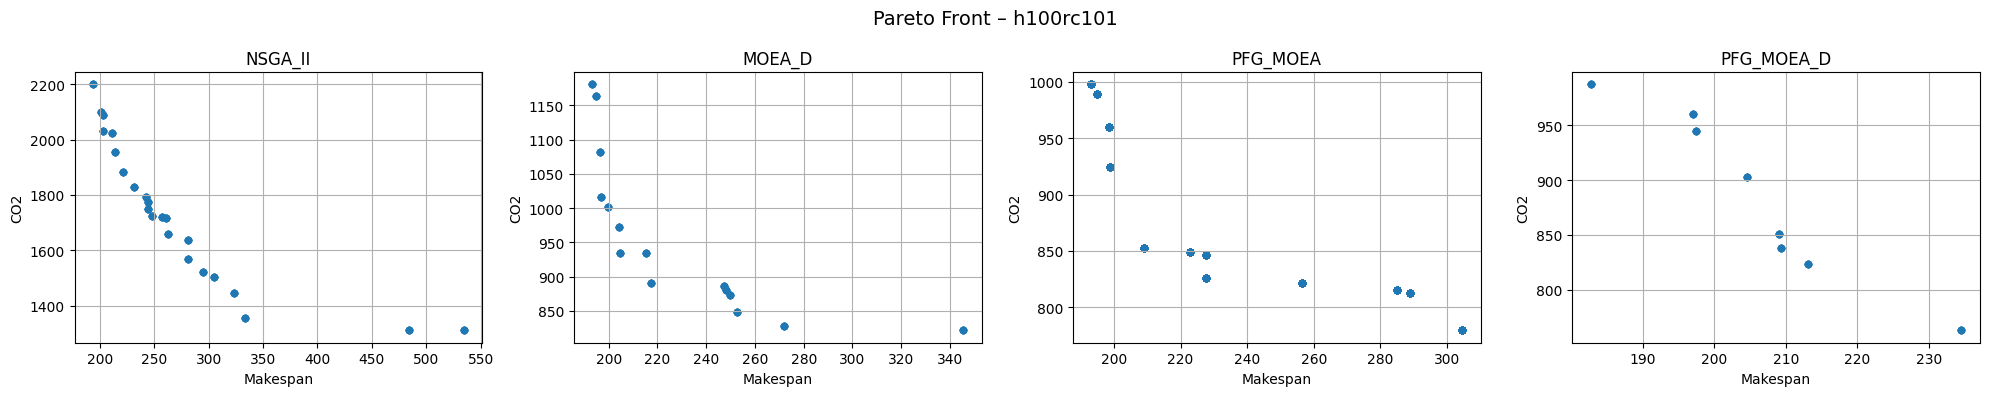

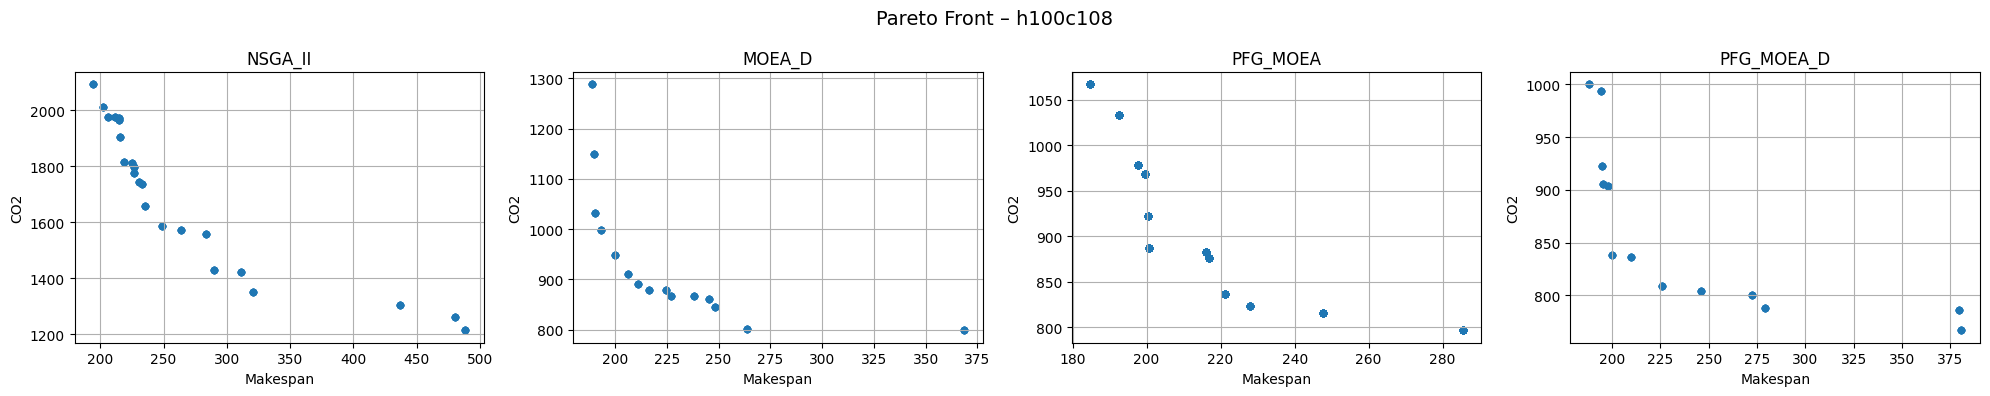

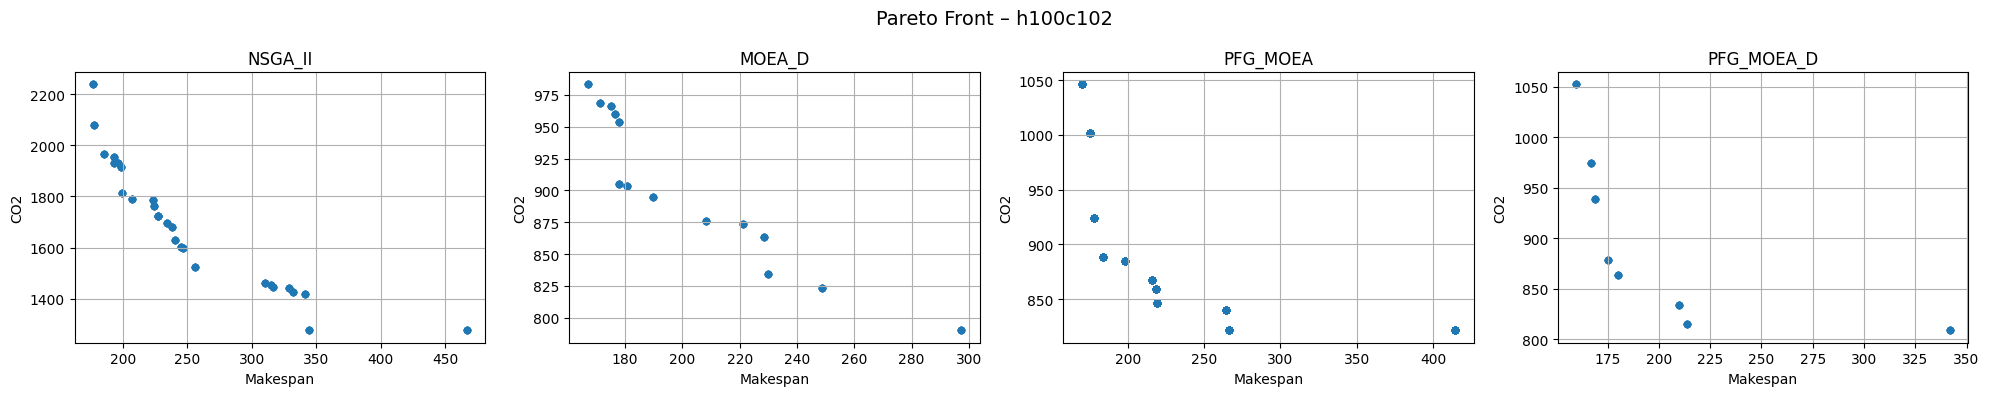

In [9]:
import os
import random
import matplotlib.pyplot as plt

# CONFIG
ALGOS_PLOT = ["NSGA_II", "MOEA_D", "PFG_MOEA", "PFG_MOEA_D"]

# Lấy tất cả instance hợp lệ
folders = sorted([
    f for f in os.listdir(RESULT_ROOT)
    if f.startswith("result_")
])

# Chọn ngẫu nhiên 3 instance
random.seed(42)
selected_folders = random.sample(folders, 3)

print("Selected instances:", selected_folders)


# PLOT 
for folder in selected_folders:

    path = os.path.join(RESULT_ROOT, folder)

    plt.figure(figsize=(20, 4))  # 1 hàng 4 hình

    for i, algo in enumerate(ALGOS_PLOT):

        f = os.path.join(path, f"pareto_{algo}.csv")

        if not os.path.exists(f):
            continue

        pf = load_pf(f)

        plt.subplot(1, 4, i+1)

        plt.scatter(pf[:, 0], pf[:, 1], s=20)

        plt.title(algo)
        plt.xlabel("Makespan")
        plt.ylabel("CO2")
        plt.grid(True)

    plt.suptitle(f"Pareto Front – {folder.replace('result_', '')}", fontsize=14)
    plt.tight_layout()
    plt.show()

Selected instances: ['result_h100rc101', 'result_h100c108', 'result_h100c102']


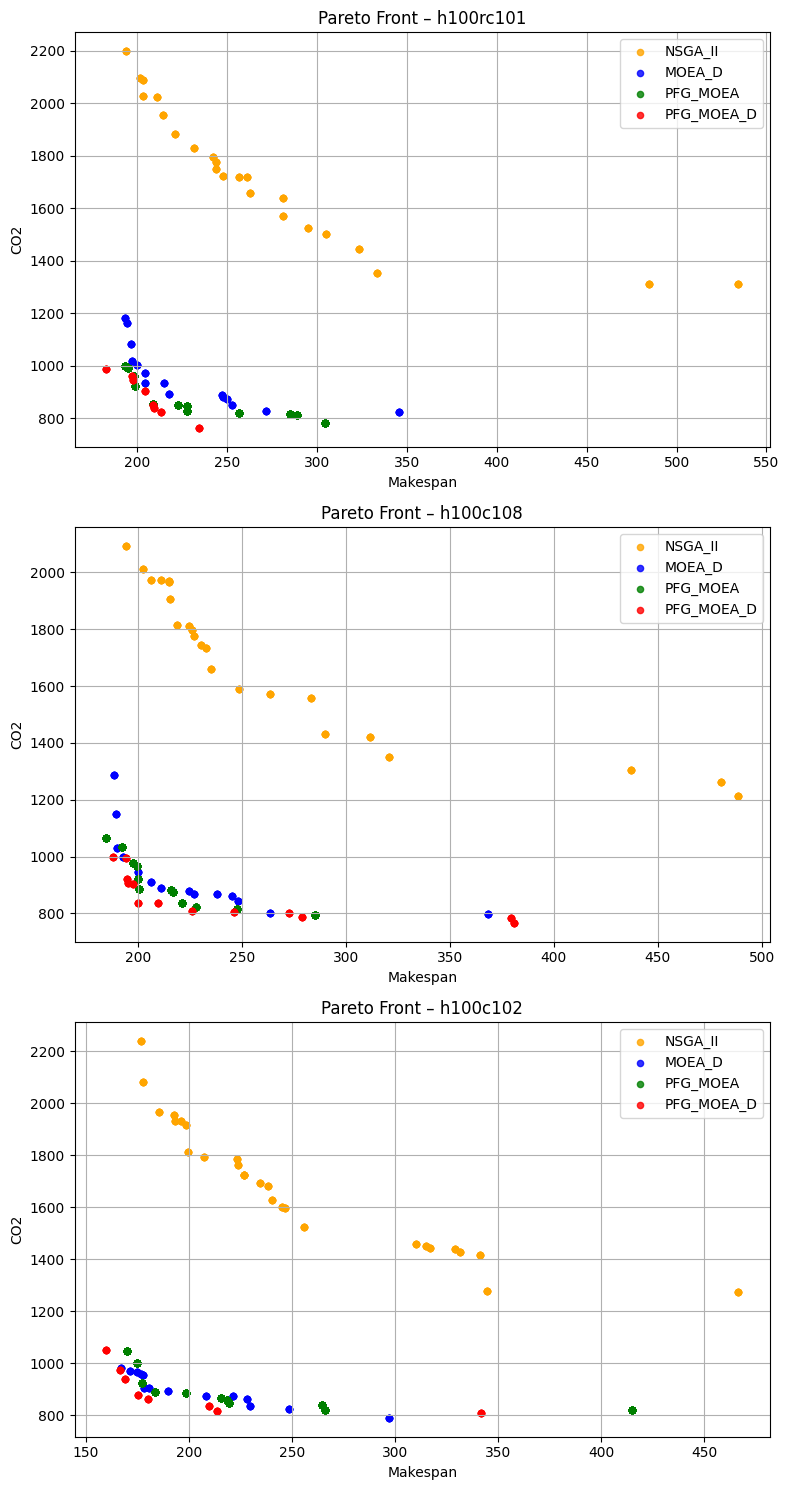

In [10]:
import os
import random
import matplotlib.pyplot as plt

# CONFIG 
RESULT_ROOT = "result_instance_5algo_with_stop_time_56"

ALGOS_PLOT = ["NSGA_II", "MOEA_D", "PFG_MOEA", "PFG_MOEA_D"]

COLORS = {
    "NSGA_II": "orange",
    "MOEA_D": "blue",
    "PFG_MOEA": "green",
    "PFG_MOEA_D": "red"
}

# LOAD PF 
def load_pf(path):
    import pandas as pd
    df = pd.read_csv(path)
    return df[["makespan", "carbon"]].values


# GET INSTANCES
folders = sorted([
    f for f in os.listdir(RESULT_ROOT)
    if f.startswith("result_")
])

# chọn 3 instance
random.seed(42)
selected_folders = random.sample(folders, 3)

print("Selected instances:", selected_folders)


# PLOT 
plt.figure(figsize=(8, 15))  # 3 hàng

for row_idx, folder in enumerate(selected_folders):

    path = os.path.join(RESULT_ROOT, folder)

    plt.subplot(3, 1, row_idx + 1)

    for algo in ALGOS_PLOT:

        f = os.path.join(path, f"pareto_{algo}.csv")

        if not os.path.exists(f):
            continue

        pf = load_pf(f)

        plt.scatter(
            pf[:, 0],
            pf[:, 1],
            s=20,
            label=algo,
            color=COLORS[algo],
            alpha=0.8
        )

    # title từng hàng
    instance_name = folder.replace("result_", "")
    plt.title(f"Pareto Front – {instance_name}")

    plt.xlabel("Makespan")
    plt.ylabel("CO2")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()


✅ Selected instance: result_h100rc108
MOEA_D → Solution 5


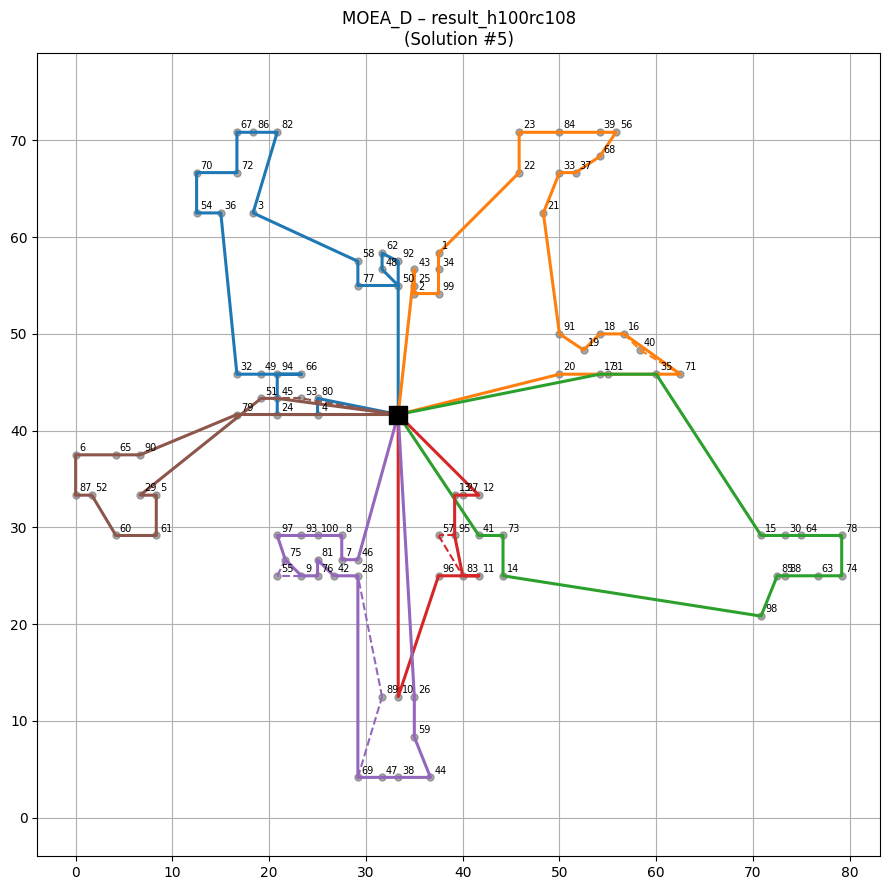

NSGA_II → Solution 3


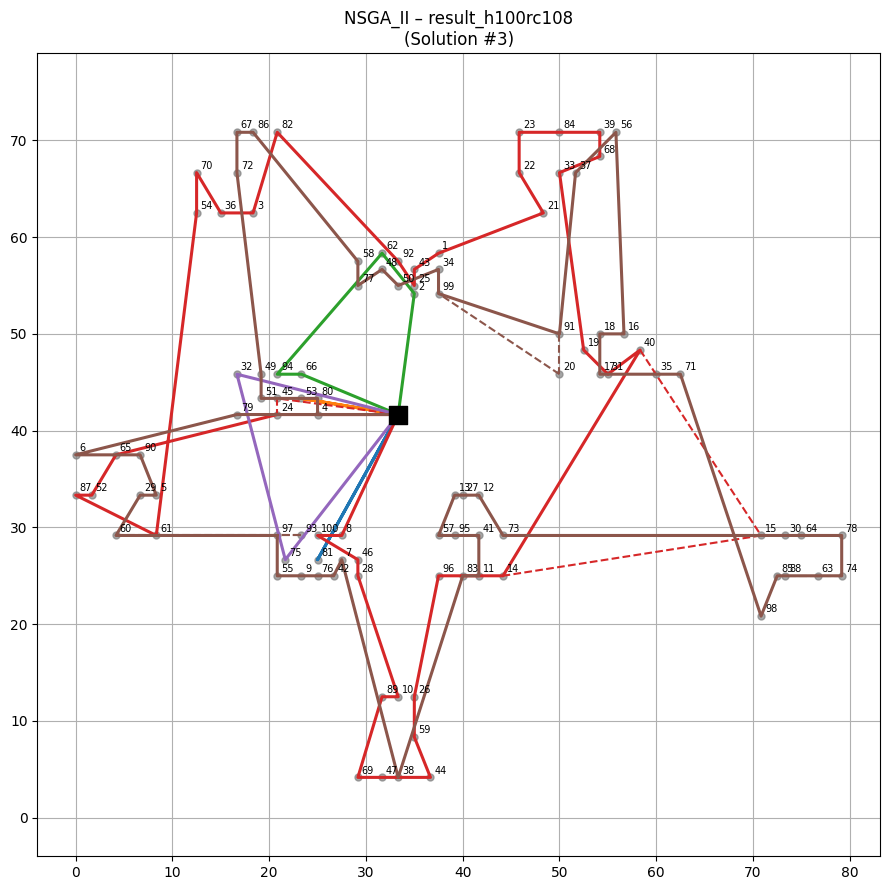

PFG_MOEA → Solution 523


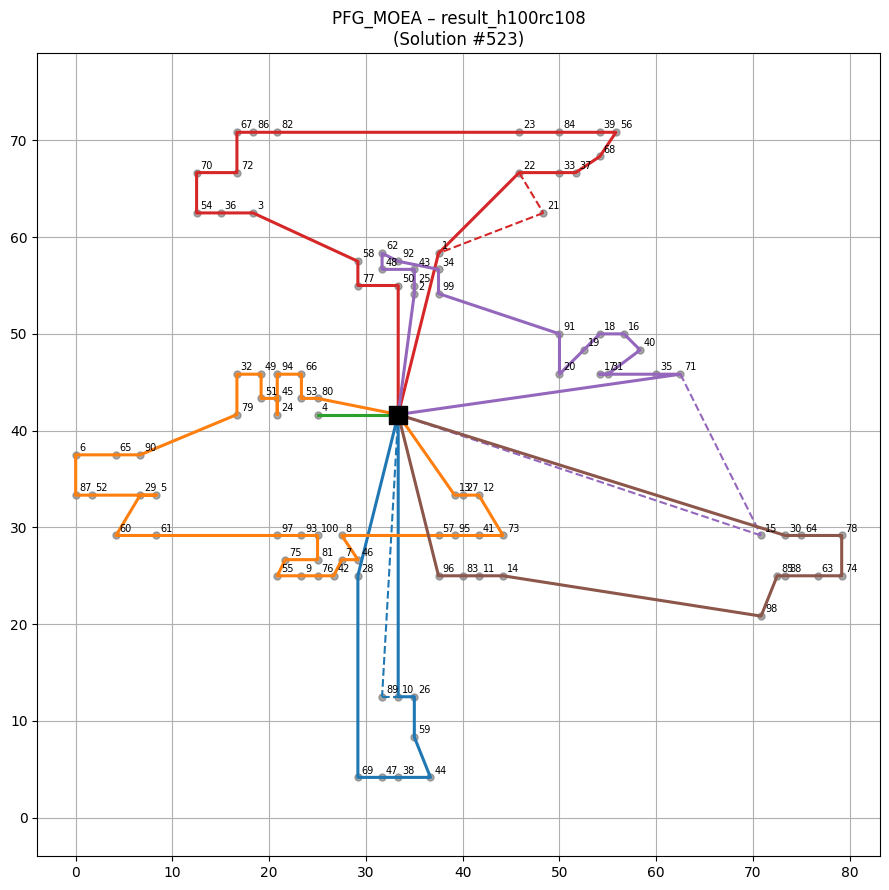

PFG_MOEA_D → Solution 2


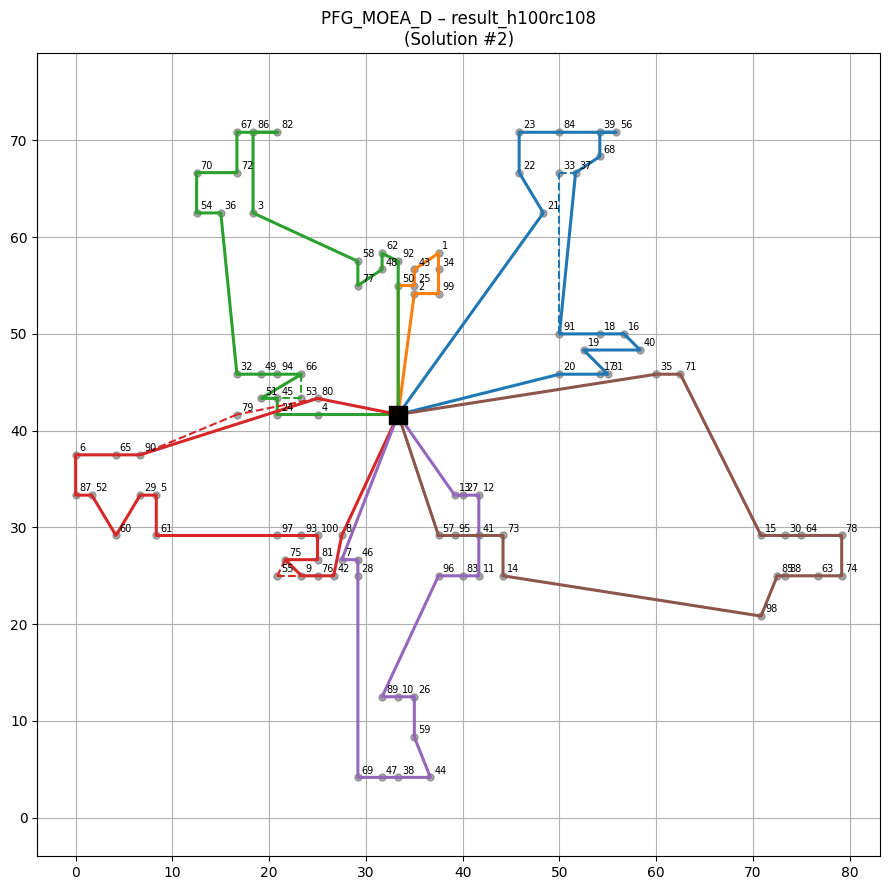

PFG_MOEA_D_VER2 → Solution 8


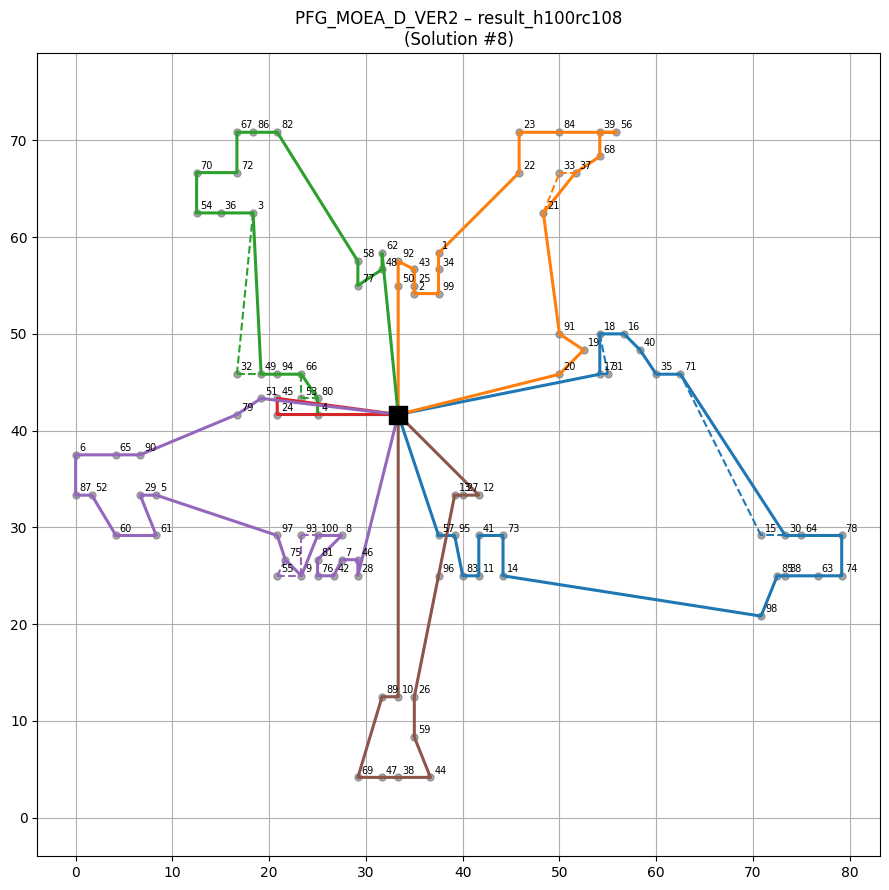

In [11]:
import os
import pandas as pd
import random
import matplotlib.pyplot as plt

# CONFIG 
RESULT_ROOT = "result_instance_5algo_with_stop_time_56"
SEED = 1

ALGOS = [
    "MOEA_D",
    "NSGA_II",
    "PFG_MOEA",
    "PFG_MOEA_D",
    "PFG_MOEA_D_VER2"   
]

# LOAD CUSTOMERS
from model.customer import Customer

def load_customers_from_csv(csv_path):
    df = pd.read_csv(csv_path)
    customers = {}

    depot = df.iloc[0]
    customers[0] = Customer(
        cid=0,
        x=float(depot["x"]),
        y=float(depot["y"]),
        demand=0.0,
        ready_time=float(depot["open"]),
        due_time=float(depot["close"]),
        service_time=0.0,
        drone_serve=False,
        time=float(depot["time"])
    )

    for idx in range(1, len(df)):
        r = df.iloc[idx]
        customers[idx] = Customer(
            cid=idx,
            x=float(r["x"]),
            y=float(r["y"]),
            demand=float(r["demand"]),
            ready_time=float(r["open"]),
            due_time=float(r["close"]),
            service_time=float(r["servicetime"]),
            drone_serve=bool(r["drone_serve"]),
            time=float(r["time"])
        )

    return customers


customers = load_customers_from_csv("data/h100c101.csv")


# REBUILD SOLUTION
class Solution:
    def __init__(self):
        self.truckRoutes = []
        self.droneCustomers = []


def parse_list_field(x):
    if pd.isna(x) or x == "":
        return []
    return list(map(int, str(x).split()))


def build_pf_from_csv(csv_path):

    df = pd.read_csv(csv_path)

    solutions = {}

    for _, row in df.iterrows():

        sid = int(row["solution_id"])
        tid = int(row["truck_id"]) - 1

        route = parse_list_field(row["truck_route"])
        drones = set(parse_list_field(row["drone_customers"]))

        if sid not in solutions:
            solutions[sid] = Solution()

        sol = solutions[sid]

        # đảm bảo đủ size
        while len(sol.truckRoutes) <= tid:
            sol.truckRoutes.append([])
            sol.droneCustomers.append(set())

        sol.truckRoutes[tid] = route
        sol.droneCustomers[tid] = drones

    # convert dict -> list theo thứ tự solution_id
    pf = [solutions[k] for k in sorted(solutions.keys())]

    return pf


# VISUALIZE 
def visualize_solution(solution, customers, title, solution_id=None):

    plt.figure(figsize=(9, 9))

    for cid, c in customers.items():
        if cid == 0:
            continue

        plt.scatter(c.x, c.y, c="gray", s=25, alpha=0.7, zorder=2)
        plt.text(c.x + 0.4, c.y + 0.4, str(cid), fontsize=7)

    depot = customers[0]
    plt.scatter(depot.x, depot.y, c="black", s=180, marker="s", zorder=5)

    cmap = plt.get_cmap("tab10")

    for t, route in enumerate(solution.truckRoutes):

        color = cmap(t % 10)
        drone_set = solution.droneCustomers[t]

        truck_stops = [0]
        for cid in route[1:-1]:
            if cid not in drone_set:
                truck_stops.append(cid)
        truck_stops.append(0)

        tx = [customers[cid].x for cid in truck_stops]
        ty = [customers[cid].y for cid in truck_stops]

        plt.plot(tx, ty, color=color, linewidth=2.2)

        rlen = len(route)

        for pos in range(1, rlen - 1):

            cid = route[pos]
            if cid not in drone_set:
                continue

            launch = next(
                route[p] for p in range(pos - 1, -1, -1)
                if route[p] == 0 or route[p] not in drone_set
            )

            recover = next(
                route[p] for p in range(pos + 1, rlen)
                if route[p] == 0 or route[p] not in drone_set
            )

            plt.plot(
                [customers[launch].x, customers[cid].x],
                [customers[launch].y, customers[cid].y],
                linestyle="--", color=color
            )

            plt.plot(
                [customers[cid].x, customers[recover].x],
                [customers[cid].y, customers[recover].y],
                linestyle="--", color=color
            )

    final_title = title
    if solution_id is not None:
        final_title += f"\n(Solution #{solution_id})"

    plt.title(final_title)
    plt.grid(True)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()


# CHỌN RANDOM INSTANCE 
folders = sorted([
    f for f in os.listdir(RESULT_ROOT)
    if f.startswith("result_")
])

chosen_folder = random.choice(folders)

print(f"\n✅ Selected instance: {chosen_folder}")

path = os.path.join(RESULT_ROOT, chosen_folder)


# LOAD PF 
pf_dict = {}

for algo in ALGOS:
    file = os.path.join(path, f"pareto_{algo}.csv")

    if os.path.exists(file):
        pf_dict[algo] = build_pf_from_csv(file)
    else:
        print(f"❌ Missing {algo}")


# RANDOM SOLUTION + VISUALIZE 
random.seed(SEED)

for algo, pf in pf_dict.items():

    if len(pf) == 0:
        continue

    sid = random.randint(1, len(pf))

    print(f"{algo} → Solution {sid}")

    visualize_solution(
        pf[sid - 1],
        customers,
        f"{algo} – {chosen_folder}",
        solution_id=sid
    )

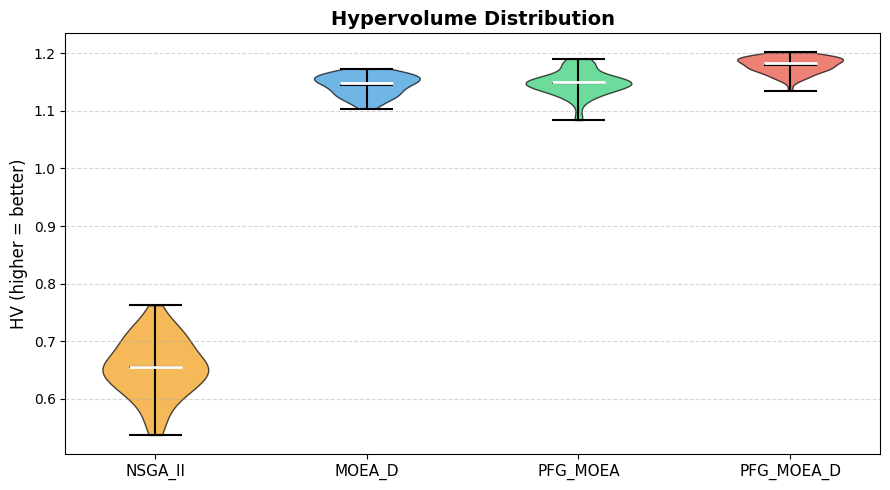

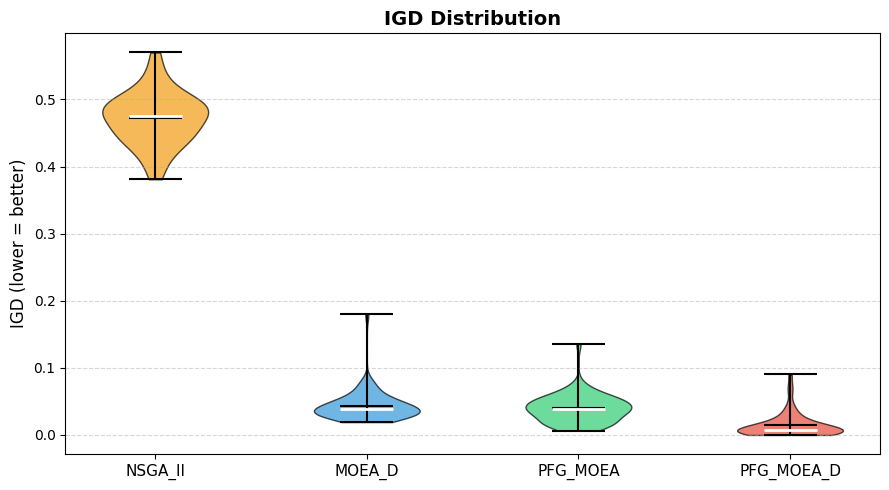

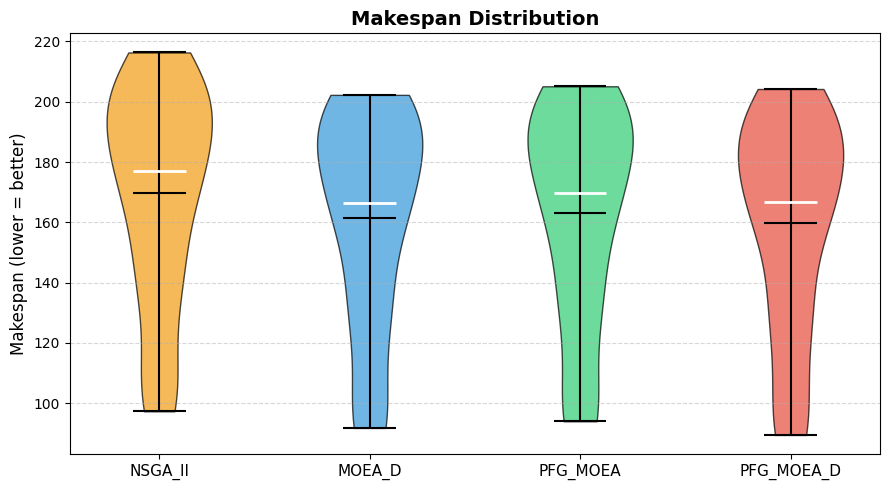

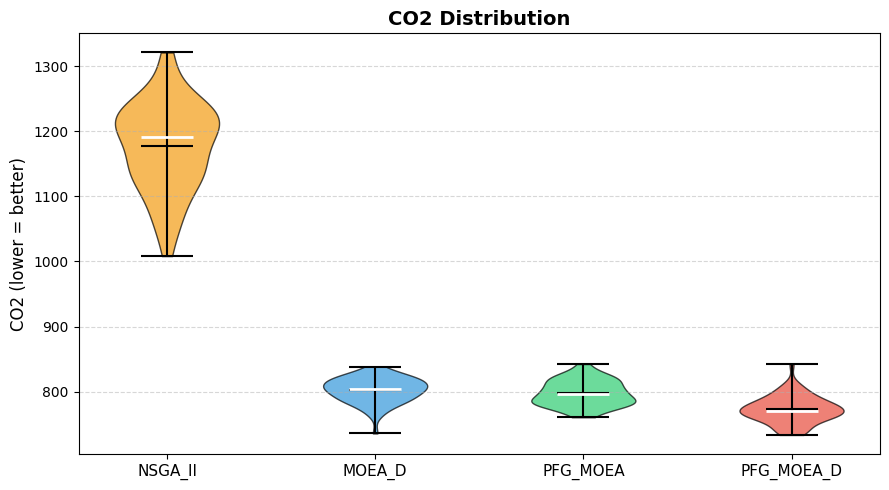

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# CONFIG 
file = "summary_results_data100.xlsx"

ALGOS = ["NSGA_II", "MOEA_D", "PFG_MOEA", "PFG_MOEA_D"]

COLORS = {
    "NSGA_II": "#f39c12",   # cam
    "MOEA_D": "#3498db",    # xanh dương
    "PFG_MOEA": "#2ecc71",  # xanh lá
    "PFG_MOEA_D": "#e74c3c" # đỏ
}

# LOAD 
df_hv  = pd.read_excel(file, sheet_name="HV")
df_igd = pd.read_excel(file, sheet_name="IGD")
df_mk  = pd.read_excel(file, sheet_name="Makespan")
df_co2 = pd.read_excel(file, sheet_name="CO2")


# VIOLIN FUNCTION 
def plot_violin(df, title, ylabel):

    data = [df[a].dropna().values for a in ALGOS]

    plt.figure(figsize=(9, 5))

    parts = plt.violinplot(
        data,
        showmeans=True,
        showmedians=True,
        showextrema=True
    )

    # TÔ MÀU 
    for i, pc in enumerate(parts['bodies']):
        algo = ALGOS[i]
        pc.set_facecolor(COLORS[algo])
        pc.set_edgecolor("black")
        pc.set_alpha(0.7)

    # STYLE mean / median 
    parts['cmeans'].set_color("black")
    parts['cmeans'].set_linewidth(1.5)

    parts['cmedians'].set_color("white")
    parts['cmedians'].set_linewidth(2)

    parts['cbars'].set_color("black")
    parts['cmins'].set_color("black")
    parts['cmaxes'].set_color("black")

    # ===== AXIS =====
    plt.xticks(range(1, len(ALGOS)+1), ALGOS, fontsize=11)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")

    plt.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


# PLOT 
plot_violin(df_hv,  "Hypervolume Distribution", "HV (higher = better)")
plot_violin(df_igd, "IGD Distribution", "IGD (lower = better)")
plot_violin(df_mk,  "Makespan Distribution", "Makespan (lower = better)")
plot_violin(df_co2, "CO2 Distribution", "CO2 (lower = better)")